<a href="https://colab.research.google.com/github/OlenaM32/CapstoneProject/blob/main/Dog_Parks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Panda

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression

In [ ]:
import pandas as pd
df = pd.read_csv('/content/Dog_Runs_20260421.csv')


Class

In [ ]:
class DogRunProject:
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path)

    def describe_source(self):
        print("Data Source: NYC Open Data - Department of Parks and Recreation.")
        print(f"The dataset contains {self.df.shape[0]} entries and {self.df.shape[1]} columns.")

# Create the object
project = DogRunProject('Dog_Runs_20260421.csv')
project.describe_source()

Data Source: NYC Open Data - Department of Parks and Recreation.
The dataset contains 92 entries and 16 columns.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92 entries, 0 to 91
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   OBJECTID         92 non-null     object
 1   SYSTEM           89 non-null     object
 2   the_geom         92 non-null     object
 3   GISPROPNUM       89 non-null     object
 4   DEPARTMENT       92 non-null     object
 5   PARENTID         89 non-null     object
 6   COMMUNITYBOARD   81 non-null     object
 7   COUNCILDISTRICT  82 non-null     object
 8   PRECINCT         84 non-null     object
 9   ZIPCODE          78 non-null     object
 10  BOROUGH          92 non-null     object
 11  DOG_AREA_TYPE    92 non-null     object
 12  NAME             92 non-null     object
 13  SEATING          22 non-null     object
 14  SURFACE          19 non-null     object
 15  FEATURESTATUS    92 non-null     object
dtypes: object(16)
memory usage: 11.6+ KB


Data Transformations

In [ ]:
def standardize_borough(code):
  mapping = {
        'M': 'Manhattan', 'B': 'Brooklyn', 'X': 'Bronx',
        'Q': 'Queens', 'R': 'Staten Island'
    }
  return mapping.get(code, 'Unknown')

df = project.df
df['borough_name'] = df['BOROUGH'].apply(standardize_borough)

#transform 1
df['seating_clean'] = df['SEATING'].fillna('No')

#transform 3
df['has_seating_binary'] = df['seating_clean'].map({'Yes': 1, 'No': 0})


In [ ]:
print(standardize_borough('M'))

Manhattan


Statistical Analysis on Chi Test

In [ ]:
# Create a cross-tabulation table
contingency_table = pd.crosstab(df['borough_name'], df['seating_clean'])

# Perform the Chi-Square test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.4f}")

Chi-Square Statistic: 0.6338
P-Value: 0.9592


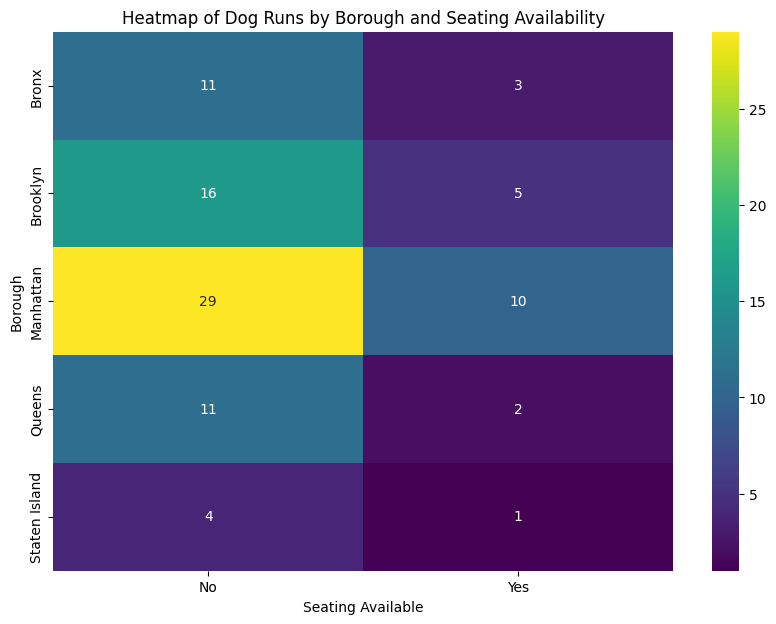

In [30]:
plt.figure(figsize=(10, 7))
sns.heatmap(contingency_table, annot=True, cmap='viridis', fmt='d')
plt.title('Heatmap of Dog Runs by Borough and Seating Availability')
plt.xlabel('Seating Available')
plt.ylabel('Borough')
plt.show()

Logistic Regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from shapely import wkt
from sklearn.linear_model import LinearRegression

class DogRunAnalysis:
    def __init__(self, file_path):
        self.df = pd.read_csv(file_path)
        self.clean_df = None
        self.model = LinearRegression()

    def transform_data(self):
        def get_poly_area(wkt_string):
            try:
                return wkt.loads(wkt_string).area
            except:
                return 0
        self.df['park_area'] = self.df['the_geom'].apply(get_poly_area)
        self.df['has_seating'] = self.df['SEATING'].fillna('No').map({'Yes': 1, 'No': 0})
        self.clean_df = self.df[self.df['park_area'] > 0] # Filter out invalid geometries

    def run_linear_regression(self):
      X = self.clean_df[['park_area']].values
      y = self.clean_df['has_seating'].values
      self.model.fit(X, y)
      return X, y, self.model.predict(X)
#process
analysis_obj = DogRunAnalysis('Dog_Runs_20260421.csv')
analysis_obj.transform_data()
x_vals, y_vals, predictions = analysis_obj.run_linear_regression()

Create linear regression graph

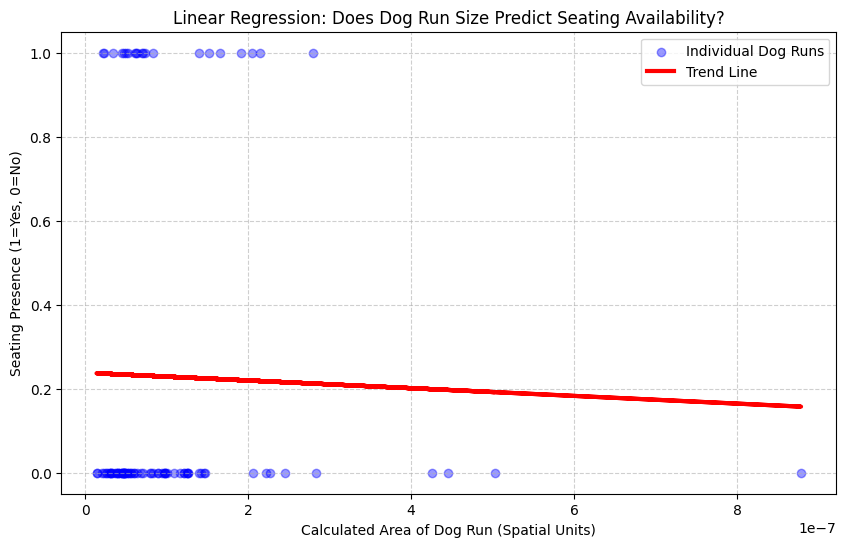

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(x_vals, y_vals, color='blue', alpha=0.4, label='Individual Dog Runs')
plt.plot(x_vals, predictions, color='red', linewidth=3, label='Trend Line')

plt.title('Linear Regression: Does Dog Run Size Predict Seating Availability?')
plt.xlabel('Calculated Area of Dog Run (Spatial Units)')
plt.ylabel('Seating Presence (1=Yes, 0=No)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Supporting Graph

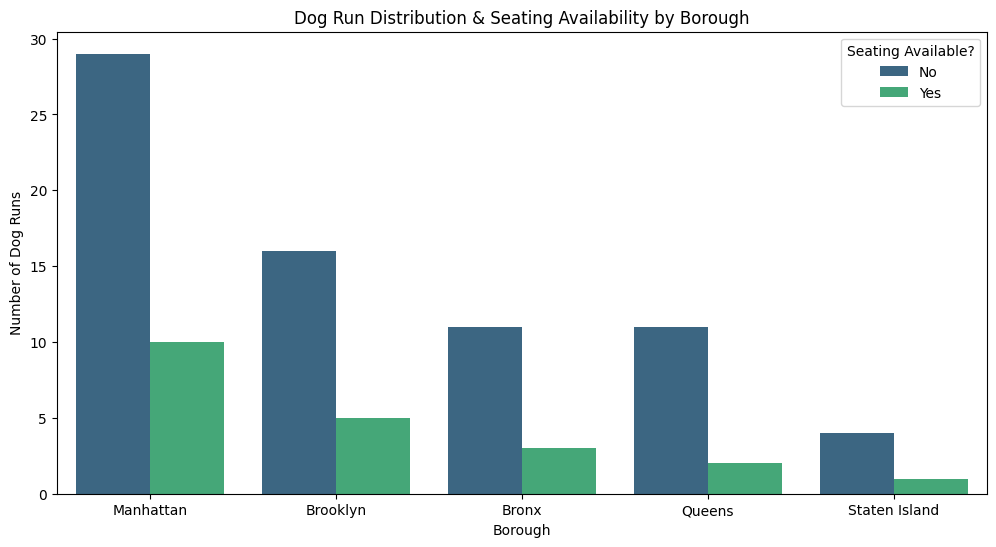

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='borough_name', hue='seating_clean', palette='viridis')

plt.title('Dog Run Distribution & Seating Availability by Borough')
plt.xlabel('Borough')
plt.ylabel('Number of Dog Runs')
plt.legend(title='Seating Available?')
plt.show()